In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
set_seed

<function __main__.set_seed(seed=42)>

In [4]:
epochs = 20
loss_history = []

In [5]:
import torch
import torch.nn.functional as F
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.0.1+cu117
11.7


In [7]:
import torch_geometric
from torch_geometric.data import Data

print("PyG OK")

p:\Anaconda\envs\torch_old\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyG OK


In [8]:
from src.datasets.gqa_graph_dataset import GQAGraphDataset, get_graph_dataloader, build_node_vocab, build_rel_vocab

In [9]:
import pandas as pd

In [10]:
df_train = pd.read_csv("../data/df_train.csv")
df_val = pd.read_csv("../data/df_val.csv")

all_labels = df_train["labels"].unique()

label2idx = {l: i for i, l in enumerate(all_labels)}
idx2label = {i: l for l, i in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"] = df_val["labels"].map(label2idx)

node_vocab = build_node_vocab(df_train)
rel_vocab = build_rel_vocab(df_train)

In [11]:
train_dataset = GQAGraphDataset(
    df=df_train,
    label_col="labels",
    node_vocab=node_vocab,
    rel_vocab=rel_vocab,
    label2idx= label2idx,
    idx2label = idx2label,
    use_bbox=True
)

val_dataset = GQAGraphDataset(
    df=df_val,
    label_col="labels",
    node_vocab=node_vocab,
    rel_vocab=rel_vocab,
    label2idx= label2idx,
    idx2label = idx2label,
    use_bbox=True
)

NUM_CLASSES = len(label2idx)

train_loader = get_graph_dataloader(
    train_dataset,
    n_classes=NUM_CLASSES,
    n_samples=4,
)

In [12]:
from src.models.gnn import GINEEmbeddingNet

In [13]:
model = GINEEmbeddingNet(
    num_node_types=len(node_vocab) + 1,
    edge_vocab_size=len(rel_vocab),
    emb_dim=128,
    hidden_dim=256,
    num_layers=4,
    dropout=0.2,
    use_bbox=True,
    node_emb_dim=64,
)

In [14]:
from src.training.contrastiveloss import supervised_contrastive_loss_GNN
from src.training.train_model import train_graph_model

In [ ]:
ckpt_dir = os.path.join(os.path.abspath(".."), "experiments", "checkpoints")
resume_from = None #os.path.join(ckpt_dir, "gnn10.pth")
resume_epoch = None  # solo se il .pth vecchio ha solo i pesi: es. 11 per continuare da epoca 11

model, history = train_graph_model(
    model=model,
    loader=train_loader,
    loss_fn=lambda emb, labels: supervised_contrastive_loss_GNN(emb, labels, temperature=0.07),
    device=device,
    epochs=epochs,
    lr=3e-4,
    weight_decay=1e-4,
    checkpoint_path=resume_from,
    resume_epoch=resume_epoch,
    save_path=os.path.join(ckpt_dir, f"gnn{epochs}.pth"),
)

p:\Anaconda\envs\torch_old\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 1/20 - loss: 3.7571 - lr: 2.98e-04
Epoch 2/20 - loss: 3.4521 - lr: 2.93e-04


In [ ]:
print(history)

[2.8080314461492066, 2.7706965332866735, 2.75309487998995, 2.7003091911220145, 2.6886390447616577, 2.6568828395798674, 2.636598777312499, 2.601647154133544, 2.5694655364649925, 2.5474530686425347, 2.511860073504285, 2.495688452679887]


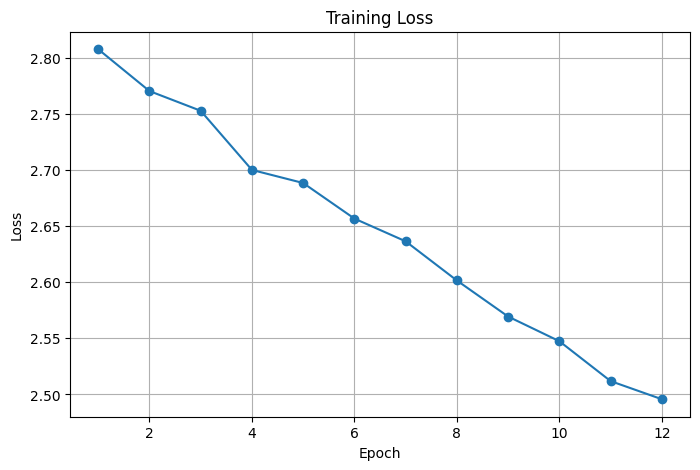

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 12 + 1), history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [ ]:
import os
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
gnne_model = GINEEmbeddingNet(
    num_node_types=len(node_vocab) + 1,
    edge_vocab_size=len(rel_vocab),
    emb_dim=128,
    hidden_dim=256,
    num_layers=4,
    dropout=0.2,
    use_bbox=True,
    node_emb_dim=64,
).to(device)

parent_dir = os.path.abspath("..")
ckpt_path = os.path.join(
    parent_dir,
    "experiments",
    "checkpoints",
    f"gnn{epochs}.pth",
)

from src.training.train_model import load_model_weights

load_model_weights(ckpt_path, gnne_model, device)
gnne_model.eval()

GINEEmbeddingNet(
  (node_encoder): Linear(in_features=5, out_features=256, bias=True)
  (edge_encoder): Embedding(308, 256)
  (convs): ModuleList(
    (0-1): 2 x GINEConv(nn=Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
    ))
  )
  (projector): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [ ]:
from src.evaluation.retrieval import (
    compute_graph_embeddings,
    evaluate_retrieval,
    print_metrics,
    plot_tsne,
)

In [ ]:
embeddings, labels = compute_graph_embeddings(
    model=gnne_model,
    dataset=val_dataset,
    device=device,
    batch_size=64,
    num_workers=0,
    normalize=True,
)

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)


results, indices, scores = evaluate_retrieval(
    embeddings,
    labels,
    ks=(1, 5, 10),
)


print_metrics(results)

Embeddings shape: torch.Size([3208, 128])
Labels shape: torch.Size([3208])

========== Retrieval Metrics ==========

acc@1               : 0.3335
precision_macro     : 0.2961
recall_macro        : 0.2894
recall@1            : 0.3335
recall@5            : 0.6849
recall@10           : 0.8201
precision@1         : 0.3335
precision@5         : 0.3168
precision@10        : 0.3164
mrr                 : 0.4807
map                 : 0.4300



In [ ]:
query_idx = 10
retrieved = indices[query_idx][1:6]
q_label = int(labels[query_idx])
print(f"Query label: {val_dataset.idx2label.get(q_label, q_label)}")
for rank, (idx, score) in enumerate(zip(retrieved, scores[query_idx][1:6]), start=1):
    lbl = int(labels[idx])
    name = val_dataset.idx2label.get(lbl, lbl)
    mark = "OK" if lbl == q_label else "MISS"
    print(f"#{rank} idx={idx} score={score:.3f} label={name} [{mark}]")

Query label: a food scene
#1 idx=1920 score=0.956 label=a person playing a sport [MISS]
#2 idx=3169 score=0.952 label=a food scene [OK]
#3 idx=1584 score=0.949 label=a food scene [OK]
#4 idx=2726 score=0.947 label=a food scene [OK]
#5 idx=699 score=0.941 label=a food scene [OK]


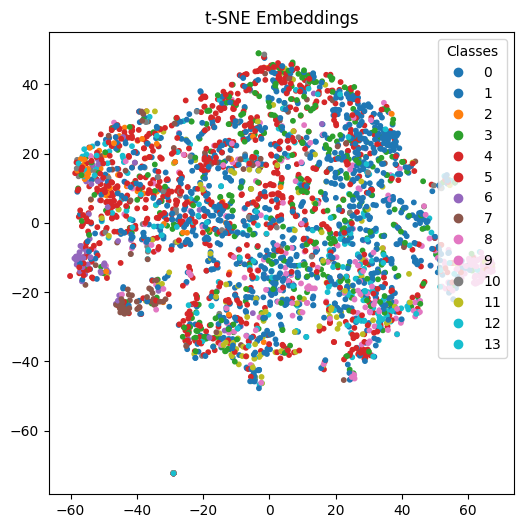

In [ ]:
plot_tsne(
    embeddings=embeddings,
    labels=labels
          )

In [ ]:
10-epoche

loss: 2.80

========== Retrieval Metrics ==========

acc@1               : 0.2930
precision_macro     : 0.2329
recall_macro        : 0.2252
recall@1            : 0.2930
recall@5            : 0.6412
recall@10           : 0.7765
precision@1         : 0.2930
precision@5         : 0.2762
precision@10        : 0.2701
mrr                 : 0.4382
map                 : 0.3884

In [ ]:
20-epoche

loss: 2.49

========== Retrieval Metrics ==========

acc@1               : 0.3335
precision_macro     : 0.2961
recall_macro        : 0.2894
recall@1            : 0.3335
recall@5            : 0.6849
recall@10           : 0.8201
precision@1         : 0.3335
precision@5         : 0.3168
precision@10        : 0.3164
mrr                 : 0.4807
map                 : 0.4300
